In [1]:
import ee
import os
import geemap
import pandas as pd
import geopandas as gpd
from pathlib import Path
import sys
import importlib
import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path().resolve().parent

sys.path.append(str(PROJECT_ROOT / "src"))

from features_utils import add_indices, correlation_matrix


In [3]:
sample_fp = PROJECT_ROOT / "outputs" / "sample_points.csv"
indices_fp = PROJECT_ROOT / "configs" / "indices.json"

samples = pd.read_csv(sample_fp)

In [4]:
samples = add_indices(samples, indices_file= indices_fp)

sample_indices_fp = PROJECT_ROOT / "outputs" / "sample_points_indices.csv"

samples.to_csv(sample_indices_fp)

In [5]:
samples.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1717 entries, 0 to 1716
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1717 non-null   int64  
 1   B11         1717 non-null   int64  
 2   B12         1717 non-null   int64  
 3   B2          1717 non-null   int64  
 4   B3          1717 non-null   int64  
 5   B4          1717 non-null   int64  
 6   B5          1717 non-null   int64  
 7   B6          1717 non-null   int64  
 8   B7          1717 non-null   int64  
 9   B8          1717 non-null   int64  
 10  B8A         1717 non-null   int64  
 11  binary      1717 non-null   int64  
 12  lat         1717 non-null   float64
 13  lc          1717 non-null   int64  
 14  location    1717 non-null   object 
 15  lon         1717 non-null   float64
 16  obs_date    1717 non-null   object 
 17  NDVI        1717 non-null   float64
 18  NDWI        1717 non-null   float64
 19  MNDWI       1717 non-null  

In [6]:
samples.describe()

,Unnamed: 0,B11,B12,B2,B3,B4,B5,B6,B7,B8,...,NDBI,NDAVI,RR1,EVI,SAVI,DVI,OSAVI,AWEI,SABI,BSI
count,1717.000000,1717.000000,1717.000000,1717.000000,1717.000000,1717.000000,1717.000000,1717.000000,1717.000000,1717.000000,...,1716.000000,1717.000000,1717.000000,1717.000000,1717.000000,1717.000000,1717.000000,1717.000000,1717.000000,1717.000000
mean,858.000000,840.877111,479.548631,378.309843,586.973209,434.921374,789.307513,1468.707630,1685.030868,1836.377985,...,-0.382878,0.451875,0.275050,1.089917,0.646986,1249.404776,0.431306,232.604397,1.513922,-0.261919
std,495.799523,827.604301,549.573959,249.790942,327.353888,349.913801,493.044617,1152.234553,1365.428365,1441.425203,...,0.277113,0.420195,0.180133,19.943315,0.597431,1317.144458,0.398589,1720.469124,1.560941,0.217033
min,0.000000,0.000000,9.000000,9.000000,31.000000,8.000000,31.000000,0.000000,0.000000,0.000000,...,-1.000000,-1.000000,-0.263158,-636.250000,-1.461538,-790.000000,-0.991649,-5917.000000,-0.494304,-0.750779
25%,429.000000,169.000000,99.000000,215.000000,368.000000,231.000000,387.000000,412.000000,432.000000,441.000000,...,-0.629129,0.150713,0.128153,0.396892,0.196319,23.000000,0.131062,-666.000000,0.140187,-0.446000
50%,858.000000,492.000000,261.000000,342.000000,573.000000,352.000000,752.000000,1289.000000,1446.000000,1724.000000,...,-0.409693,0.610490,0.277389,1.966817,0.864216,1019.000000,0.576438,293.500000,1.141436,-0.256901
75%,1287.000000,1437.000000,683.000000,481.000000,762.000000,524.000000,1106.000000,2315.000000,2632.000000,2854.000000,...,-0.200393,0.775267,0.412698,2.684789,1.128884,2144.000000,0.752702,1068.250000,2.431193,-0.101472
max,1716.000000,5342.000000,5419.000000,4296.000000,4424.000000,4464.000000,3812.000000,5708.000000,7199.000000,7256.000000,...,1.000000,0.951705,0.774648,174.090909,1.423473,6539.000000,0.949026,11800.750000,7.862302,0.547619


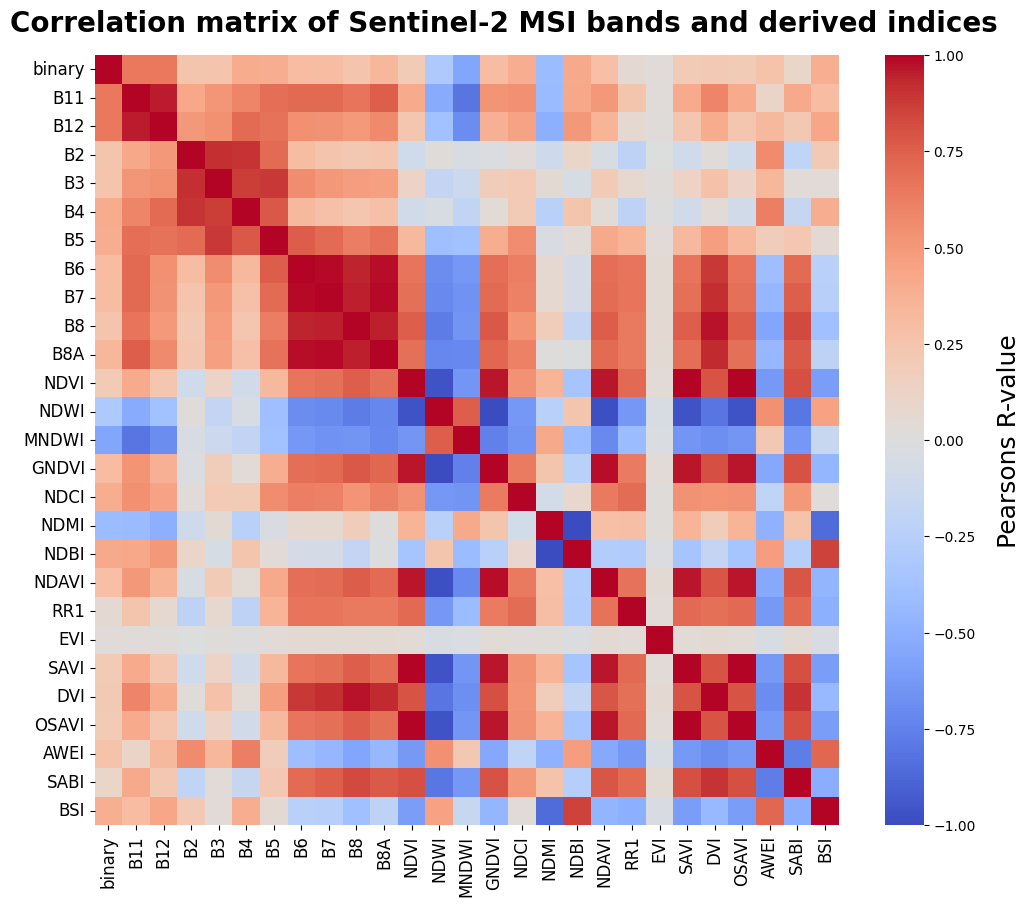

KeyError: 'lc'

In [ ]:
corr = correlation_matrix(samples, columns= ['binary','B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8',
       'B8A', 'NDVI', 'NDWI',
       'MNDWI', 'GNDVI', 'NDCI', 'NDMI', 'NDBI', 'NDAVI', 'RR1', 'EVI', 'SAVI',
       'DVI', 'OSAVI', 'AWEI', 'SABI', 'BSI'])



In [11]:
print(samples.columns)

Index(['Unnamed: 0', 'B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8',
       'B8A', 'lat', 'lc', 'location', 'lon', 'obs_date', 'NDVI', 'NDWI',
       'MNDWI', 'GNDVI', 'NDCI', 'NDMI', 'NDBI', 'NDAVI', 'RR1', 'EVI', 'SAVI',
       'DVI', 'OSAVI', 'AWEI', 'SABI', 'BSI'],
      dtype='object')


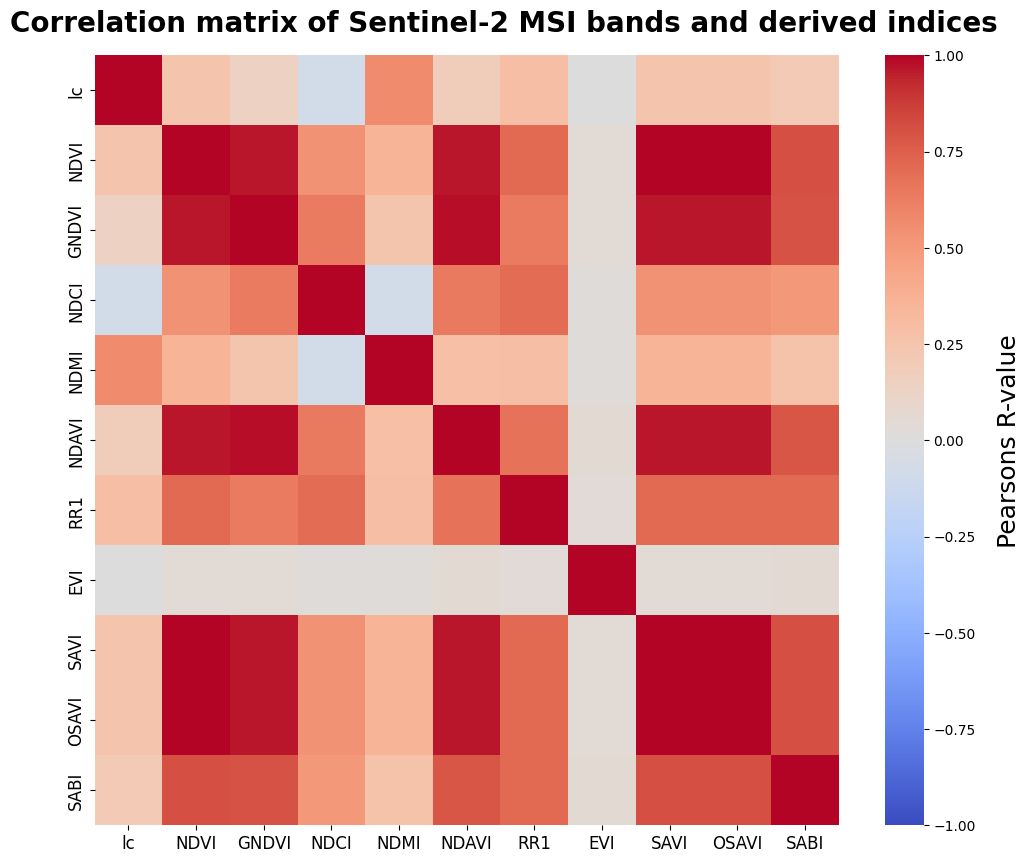

In [8]:
veg_columns = ['lc','NDVI','GNDVI', 'NDCI', 'NDMI','NDAVI', 'RR1', 'EVI', 'SAVI','OSAVI', 'SABI']

veg_corr = correlation_matrix(samples, columns= veg_columns)